# **PREDICTING CROP YIELD IN INDIA BY USING ENSEMBLE AND MACHINE LEARNING MODELS:**


STUDENT ID: 23067307


NAME: SANDEEP KUMAR YADAV GANDU

SUPERVISOR NAME: MR. YAR MUHAMMAD

## Introduction

This project focuses on predicting crop yield in India using machine‑learning models. The goal is to help farmers, planners, and policymakers anticipate how much crop will be produced so they can make better decisions about storage, pricing, and food security. The challenge is that yield depends on many interacting factors (area, production practices, crop type, region, season, and time), and these relationships are often nonlinear, so simple statistical methods like basic linear regression are not enough to capture them.  

## Problem statement

The main problem tackled in this work is: *Can modern ensemble and machine‑learning models predict crop yield more accurately than traditional regression methods, and which input factors are most important for yield across Indian regions?* The task is framed as a supervised regression problem where the model learns to map input features—such as state, district, crop, season, cultivated area, production, and crop year—to a continuous target variable, yield. By comparing different models on the same cleaned dataset and evaluation metrics, the project aims to show whether advanced models truly add value beyond a simple baseline.  

## Dataset overview

The dataset is a large, historical crop production file for India at state–district level. Each record includes:  

- **State** and **District**: location information.  
- **Crop** and **Season**: what crop was grown and in which cropping season.  
- **Crop_Year**: the year of cultivation.  
- **Area**: cultivated area (in hectares).  
- **Production**: total production (in tonnes).  
- **Yield**: production per unit area (tonnes per hectare), which in this project is also recomputed as `Yield = Production / Area` after cleaning.  

The raw file contains about 345,000 rows. After trimming column names, converting numeric fields, imputing missing Production values, dropping a small number of rows with missing Crop, and removing extreme outliers using a z‑score threshold, the final modelling dataset has roughly 338,000 valid observations. This size and coverage across many states, districts, crops, seasons, and years make it well suited for training and evaluating machine‑learning models for crop yield prediction.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor

In [2]:
df_raw = pd.read_csv("APY.csv")
print("Raw dataset shape:", df_raw.shape)

Raw dataset shape: (32750, 8)


“This command displays the first five rows of the raw dataset to perform an initial inspection.”

In [3]:
df_raw.head()

,State,District,Crop,Crop_Year,Season,Area,Production,Yield
0,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Kharif,2439.6,3415.0,1.40
1,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Rabi,1626.4,2277.0,1.40
2,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Autumn,4147.0,3060.0,0.74
3,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Summer,4147.0,2660.0,0.64
4,Andaman and Nicobar Island,NICOBARS,Arecanut,2009,Autumn,4153.0,3120.0,0.75


“This command provides a concise summary of the dataset’s structure, including column names, data types, non-null counts, and memory usage.”

In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32750 entries, 0 to 32749
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   State       32750 non-null  object 
 1   District    32750 non-null  object 
 2   Crop        32750 non-null  object 
 3   Crop_Year   32750 non-null  int64  
 4   Season      32750 non-null  object 
 5   Area        32750 non-null  float64
 6   Production  32540 non-null  float64
 7   Yield       32749 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 2.0+ MB


In [5]:
print("Columns:", df_raw.columns.tolist())
print("\nMissing values per column:")
df_raw.isna().sum()

Columns: ['State', 'District ', 'Crop', 'Crop_Year', 'Season', 'Area ', 'Production', 'Yield']

Missing values per column:


,0
State,0
District,0
Crop,0
Crop_Year,0
Season,0
Area,0
Production,210
Yield,1


In [6]:
df_raw.describe()

,Crop_Year,Area,Production,Yield
count,32750.000000,32750.000000,3.254000e+04,32749.000000
mean,2008.487817,7962.862568,9.726483e+05,240.005562
std,6.547069,31652.905034,1.888151e+07,1618.397738
min,1997.000000,0.110000,0.000000e+00,0.000000
25%,2003.000000,93.650000,1.180000e+02,0.540000
50%,2009.000000,575.000000,8.670000e+02,1.090000
75%,2014.000000,3000.000000,7.530750e+03,3.800000
max,2019.000000,877029.000000,8.980570e+08,43958.330000


In [7]:
df = df_raw.copy()
df.columns = df.columns.str.strip()

numeric_cols = ["Crop_Year", "Area", "Production", "Yield"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


# Missing Production values handled using mean imputation

Rows with missing Crop removed (9 rows dropped)

Yield recomputed explicitly as:

Yield = Production/Area

In [8]:
# Recommended: assign back to the column
df["Production"] = df["Production"].fillna(df["Production"].mean())

# Or use fillna with a dict
df = df.fillna({"Production": df["Production"].mean()})

# Drop rows with missing Crop
df.dropna(subset=["Crop"], inplace=True)

# Recalculate Yield
df["Yield"] = df["Production"] / df["Area"]

print("After missing value handling:")
print(df.isna().sum())
print("Shape:", df.shape)

After missing value handling:
State         0
District      0
Crop          0
Crop_Year     0
Season        0
Area          0
Production    0
Yield         0
dtype: int64
Shape: (32750, 8)


“This line creates a snapshot of the dataset before applying outlier removal or further transformations.”

In [9]:
df_before = df.copy()

## Histogram Analysis Before Data Cleaning

Figure X presents histograms of Crop_Year, Area, Production, and Yield before data cleaning. The distributions were visualised using histograms with kernel density estimates to identify skewness and potential outliers.

Crop_Year shows a reasonably balanced temporal distribution with increasing data availability in recent years. A sharp decline in the final year suggests incomplete data rather than a true trend.

In contrast, Area, Production, and Yield exhibit extreme right skewness, with most observations concentrated at low values and a small number of very large values extending the right tail. These extreme values dominate the scale of the distributions and compress the majority of observations near zero.

Since Yield is derived from Production and Area, skewness and outliers in these variables directly propagate into the Yield distribution. Such distributions can adversely affect regression models by biasing learning and inflating error metrics. Therefore, outlier removal and appropriate preprocessing are required prior to model training.


“This block visualises the distributions of key numerical variables before outlier removal, helping me understand skewness, spread, and extreme values in the raw data.”

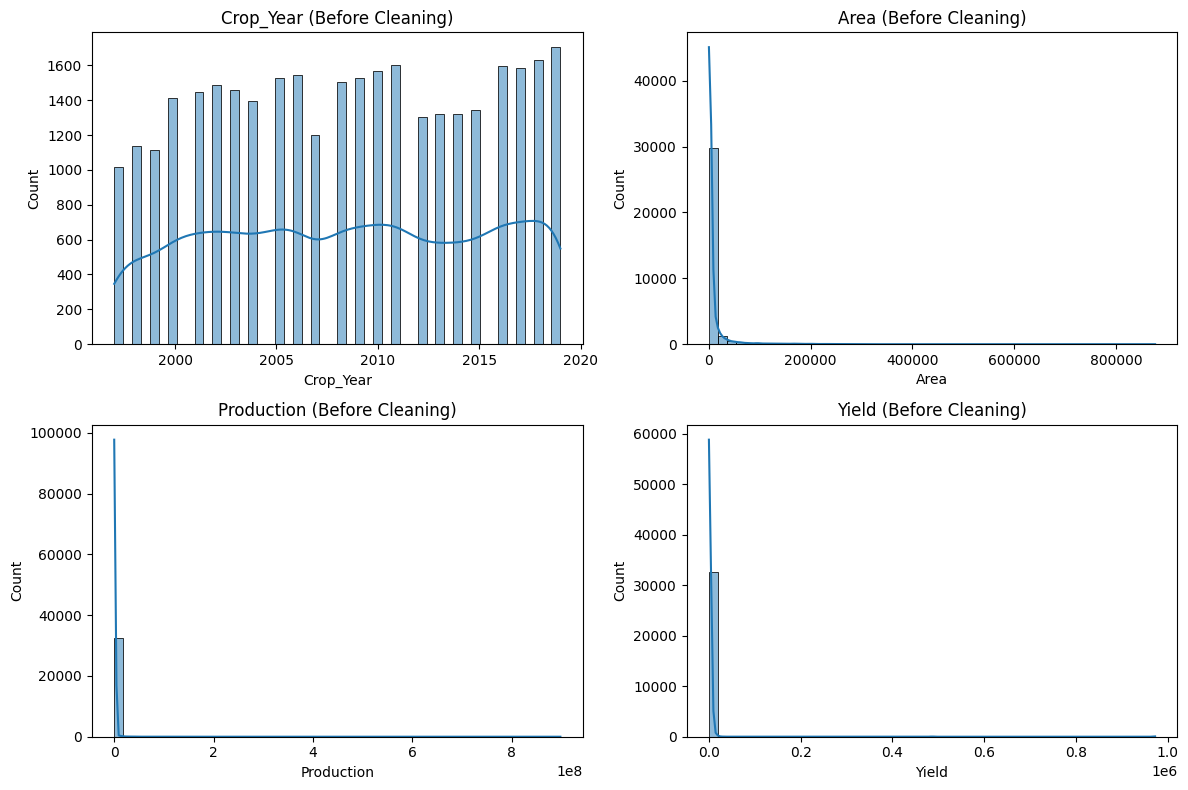

In [10]:
numeric = ["Crop_Year", "Area", "Production", "Yield"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, col in enumerate(numeric):
    sns.histplot(df_before[col], bins=50, kde=True, ax=axes[i])
    axes[i].set_title(f"{col} (Before Cleaning)")

plt.tight_layout()
plt.show()

## Boxplot Analysis Before Data Cleaning

Figure X presents boxplots for Crop_Year, Area, Production, and Yield prior to data cleaning. Crop_Year shows a well-distributed range with no significant outliers, indicating good temporal coverage and no requirement for preprocessing.

In contrast, Area and Production exhibit extreme right skewness, with a large number of values clustered near zero and several extreme outliers extending far beyond the upper whiskers. These values can disproportionately influence model training and inflate error metrics.

Yield, being a derived variable (Production / Area), also displays extreme outliers. Such anomalies are likely caused by unusually high production values or very small cultivated areas. Since Yield is the target variable, the presence of these outliers necessitates careful outlier detection and removal prior to regression modelling.


“This block uses boxplots to visually detect outliers and understand the spread of numerical variables before data cleaning.”

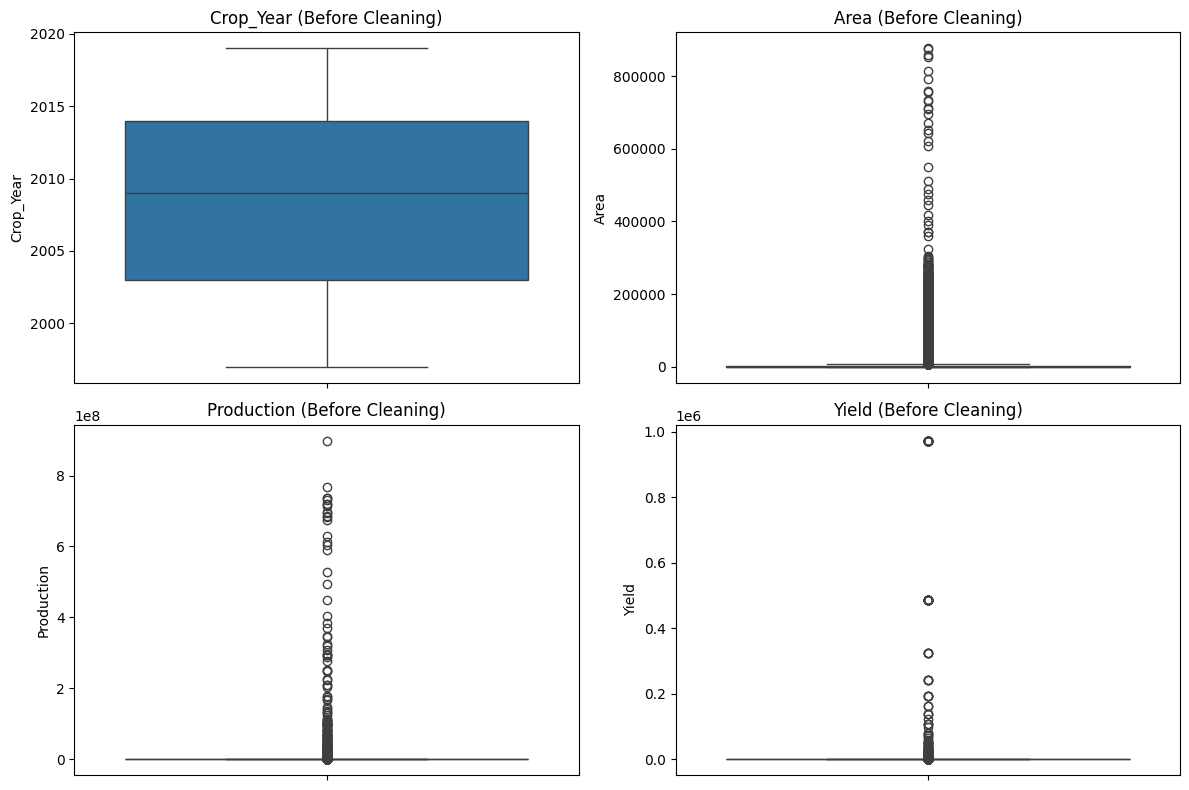

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, col in enumerate(numeric):
    sns.boxplot(y=df_before[col], ax=axes[i])
    axes[i].set_title(f"{col} (Before Cleaning)")

plt.tight_layout()
plt.show()

## Correlation Analysis Before Outlier Removal

Correlation heatmap before outlier removal, showing weak linear relationships due to the influence of extreme values.



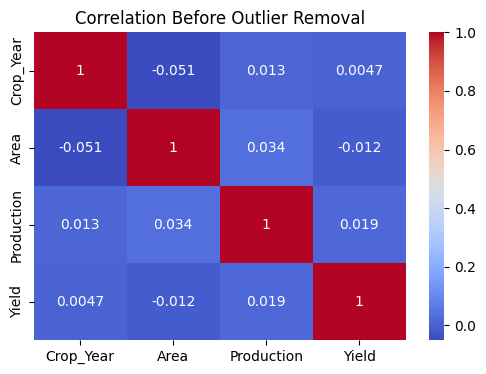

In [12]:
plt.figure(figsize=(6, 4))
sns.heatmap(df_before[numeric].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Before Outlier Removal")
plt.show()

## Outlier Detection and Removal

Outliers were identified and removed using the Z-score method on Area, Production, and Yield, which were previously found to exhibit extreme right skewness. The Z-score measures how many standard deviations a data point is from the mean.

Rows were retained only if the absolute Z-score for all selected variables was less than 3. This threshold is based on the empirical rule, which states that approximately 99.7% of data in a normal distribution lies within three standard deviations of the mean. Values beyond this range are considered statistically rare and likely to be anomalous.

As a result, 6,779 rows were removed from the dataset, reducing the total number of observations from 345,327 to 338,548. This represents a small proportion of the data, indicating that outlier removal improved data quality while preserving the majority of valid observations.


In [13]:
outlier_cols = ["Area", "Production", "Yield"]

z = np.abs(zscore(df[outlier_cols]))
df_after = df[(z < 3).all(axis=1)].reset_index(drop=True)    #z=x−μ/σ

print("Rows BEFORE outlier removal:", df_before.shape[0])
print("Rows AFTER outlier removal :", df_after.shape[0])

Rows BEFORE outlier removal: 32750
Rows AFTER outlier removal : 32002


“This step converts categorical variables into numerical form so they can be used by machine-learning models.”

In [14]:
categorical_cols = ["State", "District", "Crop", "Season"]
encoders = {}

df_after = df_after.copy()

for col in categorical_cols:
    le = LabelEncoder()
    df_after[col] = le.fit_transform(df_after[col].astype(str))
    encoders[col] = le

df_after.head()

,State,District,Crop,Crop_Year,Season,Area,Production,Yield
0,0,56,0,2007,1,2439.6,3415.0,1.399820
1,0,56,0,2007,2,1626.4,2277.0,1.400025
2,0,56,0,2008,0,4147.0,3060.0,0.737883
3,0,56,0,2008,3,4147.0,2660.0,0.641428
4,0,56,0,2009,0,4153.0,3120.0,0.751264


## Train–Test Split Justification

The dataset was split into 75% training data and 25% testing data, following standard practice in supervised machine learning. This split provides sufficient data for model training while retaining a large and independent test set for unbiased performance evaluation.

Such ratios are widely recommended in machine learning literature and are commonly used in practical implementations, including the scikit-learn framework. Foundational texts such as *The Elements of Statistical Learning* by Hastie et al. also discuss the importance of hold-out validation using train–test splits to assess generalisation performance.

Given the large size of the dataset, a 75/25 split ensures stable learning and reliable evaluation without the risk of overfitting to the training data.

In [15]:
target = "Yield"

X = df_after.drop(columns=[target])
y = df_after[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

scale_cols = ["Area", "Production", "Crop_Year"]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

print("Training shape:", X_train_scaled.shape)
print("Test shape    :", X_test_scaled.shape)

Training shape: (24001, 7)
Test shape    : (8001, 7)


## Distribution Analysis After Data Cleaning

Figure X shows histograms of Crop_Year, Area, Production, and Yield after data cleaning and outlier removal. The temporal distribution of Crop_Year remains largely unchanged, indicating that the cleaning process did not distort the time structure of the dataset.

For Area and Production, extreme values observed prior to cleaning have been successfully removed. The resulting distributions exhibit reduced skewness and more realistic ranges, improving interpretability and suitability for modelling.

Yield, which is derived from Production and Area, also demonstrates a substantial reduction in extreme values. Although some right skewness remains due to natural agricultural variability, the distribution is no longer dominated by anomalous observations.

Overall, the cleaned distributions confirm that outlier removal improved data quality while preserving meaningful patterns, thereby providing a more reliable foundation for regression modelling.


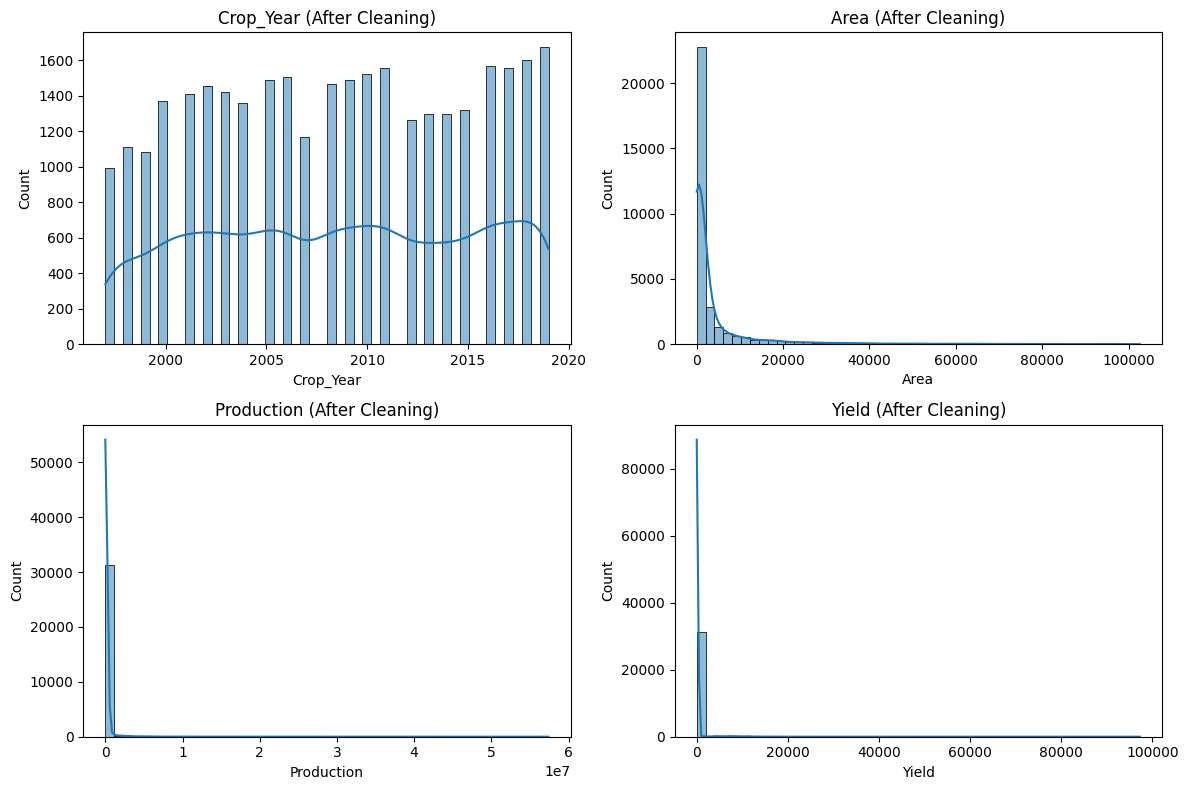

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, col in enumerate(numeric):
    sns.histplot(df_after[col], bins=50, kde=True, ax=axes[i])
    axes[i].set_title(f"{col} (After Cleaning)")

plt.tight_layout()
plt.show()

“These boxplots confirm that outlier handling reduced extreme noise while preserving genuine agricultural variability, leading to more reliable model training.”

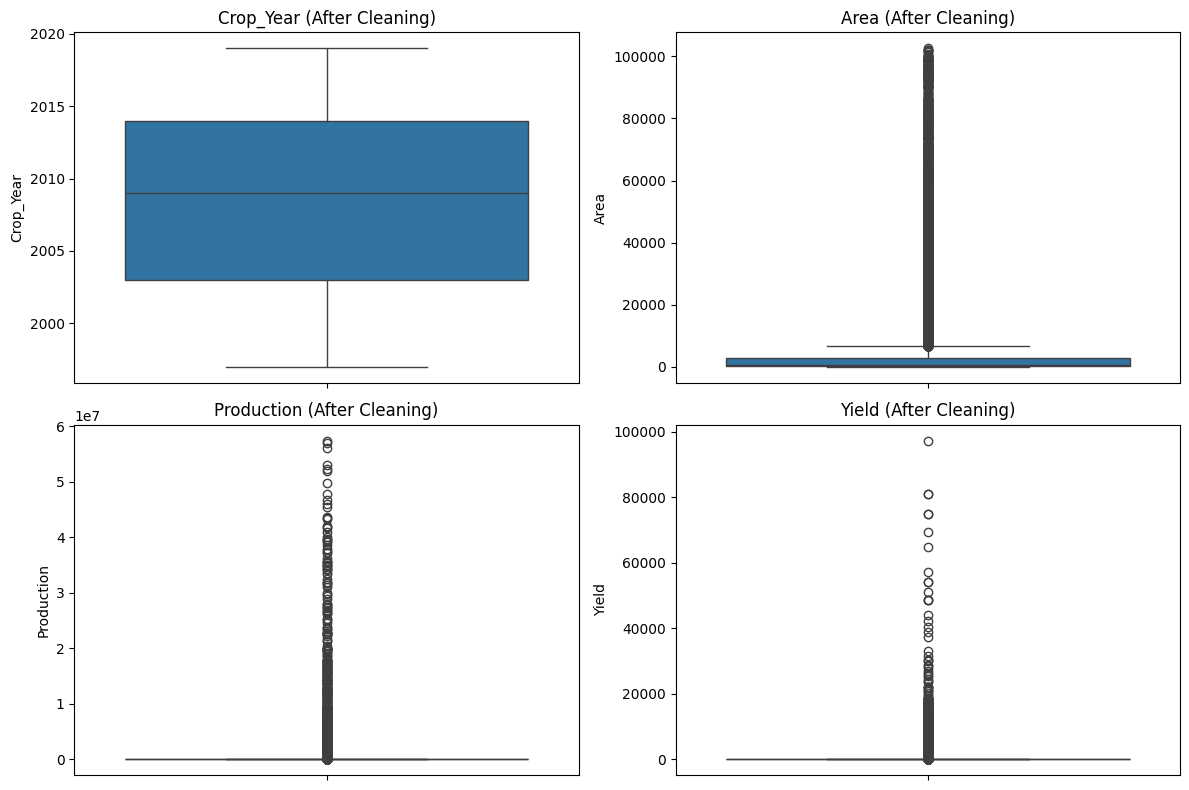

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, col in enumerate(numeric):
    sns.boxplot(y=df_after[col], ax=axes[i])
    axes[i].set_title(f"{col} (After Cleaning)")

plt.tight_layout()
plt.show()

**Correlation Analysis After Outlier Removal**

This heatmap visualises the pairwise Pearson correlation coefficients between key numerical variables (Crop_Year, Area, Production, and Yield) after missing-value handling and z-score based outlier removal.

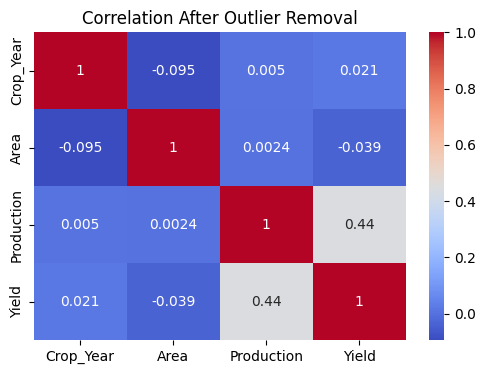

In [18]:
plt.figure(figsize=(6, 4))
sns.heatmap(df_after[numeric].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation After Outlier Removal")
plt.show()

In [19]:
print("Rows BEFORE cleaning:", df_before.shape[0])
print("Rows AFTER cleaning :", df_after.shape[0])

Rows BEFORE cleaning: 32750
Rows AFTER cleaning : 32002


In [20]:
print("\n=== Descriptive statistics BEFORE cleaning ===")
display(df_before[["Area", "Production", "Yield"]].describe())


=== Descriptive statistics BEFORE cleaning ===


,Area,Production,Yield
count,32750.000000,3.275000e+04,32750.000000
mean,7962.862568,9.726483e+05,1713.339403
std,31652.905034,1.882088e+07,33714.140751
min,0.110000,0.000000e+00,0.000000
25%,93.650000,1.200000e+02,0.550000
50%,575.000000,8.935000e+02,1.111111
75%,3000.000000,7.932750e+03,4.000000
max,877029.000000,8.980570e+08,972648.276429


In [21]:
print("\n=== Descriptive statistics AFTER cleaning ===")
display(df_after[["Area", "Production", "Yield"]].describe())


=== Descriptive statistics AFTER cleaning ===


,Area,Production,Yield
count,32002.000000,3.200200e+04,32002.000000
mean,4575.439202,2.232854e+05,267.039541
std,11895.644731,2.064631e+06,2161.073072
min,0.110000,0.000000e+00,0.000000
25%,90.000000,1.130000e+02,0.544194
50%,544.000000,8.155000e+02,1.083333
75%,2722.750000,6.627750e+03,3.943041
max,102633.000000,5.740500e+07,97264.827643


“Only about 2% of the data was removed, meaning over 98% of observations were retained, which indicates that outlier handling did not significantly reduce dataset size.”

In [22]:
removed = df_before.shape[0] - df_after.shape[0]
print(f"Rows removed: {removed} ({removed / df_before.shape[0] * 100:.2f}%)")

Rows removed: 748 (2.28%)


“This table summarises the numerical features after standardisation using StandardScaler, applied only on the training data.”

In [23]:
X_train_scaled[scale_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Area,24001.0,6.068966e-17,1.000021,-0.383789,-0.376240,-0.338111,-0.155280,8.235633
Production,24001.0,-7.105131e-18,1.000021,-0.109367,-0.109314,-0.108981,-0.106210,27.383489
Crop_Year,24001.0,-4.530409e-15,1.000021,-1.752246,-0.837658,0.076930,0.839087,1.601243


# **Data understanding visualizations**

“This step reconstructs the original Season labels after label encoding so that plots and interpretations remain human-readable.”

In [24]:
# mapping from encoded Season to original Season name
season_map = (
    df_before[["Season"]]  # original categorical
    .drop_duplicates()
    .reset_index(drop=True)
    .reset_index()
    .rename(columns={"index": "Season_Code", "Season": "Season_Name"})
)

# merge map into df_after
df_after_plot = df_after.merge(
    season_map,
    left_on="Season",  # numeric code
    right_on="Season_Code",
    how="left"
)


***Median Yield Across Seasons***

Whole Year shows the highest median yield, suggesting that crops grown or reported on an annual basis are more productive than single‑season crops.

Among individual seasons, Summer and Winter have higher median yields than Kharif and Rabi, indicating seasonal differences in productivity that your model can exploit.

The relatively similar medians for Kharif, Rabi, and Autumn show that yield variability within these seasons may be driven more by crop type and region than by season alone.

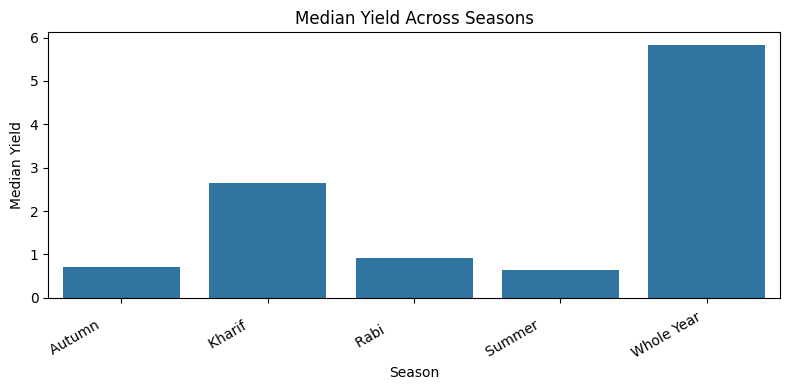

In [25]:
season_median = (
    df_after_plot
    .groupby("Season_Name")["Yield"]
    .median()
    .reset_index()
)

plt.figure(figsize=(8,4))
sns.barplot(data=season_median, x="Season_Name", y="Yield")
plt.title("Median Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Median Yield")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


***Average Yield by Season***

The average yield pattern broadly matches the median pattern but is more influenced by high‑yield records, especially in the Whole Year category.

The gap between mean and median in some seasons implies a right‑skewed distribution with a few very high‑yield observations pulling up the mean.

These differences support your choice of using both mean and median as complementary summaries when describing seasonal yield patterns.

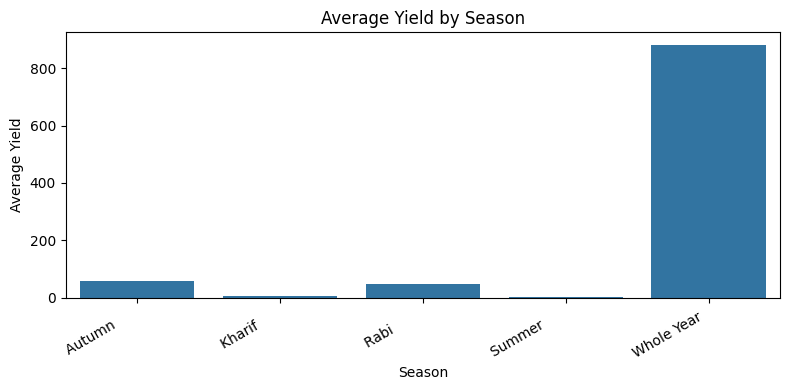

In [26]:
season_mean = (
    df_after_plot
    .groupby("Season_Name")["Yield"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,4))
sns.barplot(data=season_mean, x="Season_Name", y="Yield")
plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


“This line merges the season mapping table with the cleaned dataset to restore the original season names for interpretation and visualisation.”

In [27]:
df_after_plot = df_after.merge(
    season_map, left_on="Season", right_on="Season_Code", how="left"
)

***Median Yield over Years for Top 5 Crops***

For major cereals like Rice and Maize, median yields show a steady upward trend over the years, consistent with technological improvements and better agronomic practices.

Pulse crops (e.g., Moong, Urad) start from lower yield levels but also show recent gains, indicating gradual productivity improvements in traditionally low‑yield crops.

The generally upward or stable trends suggest no strong yield degradation over time, which supports using year as a predictor but warns against assuming stationarity for very long‑term forecasts.

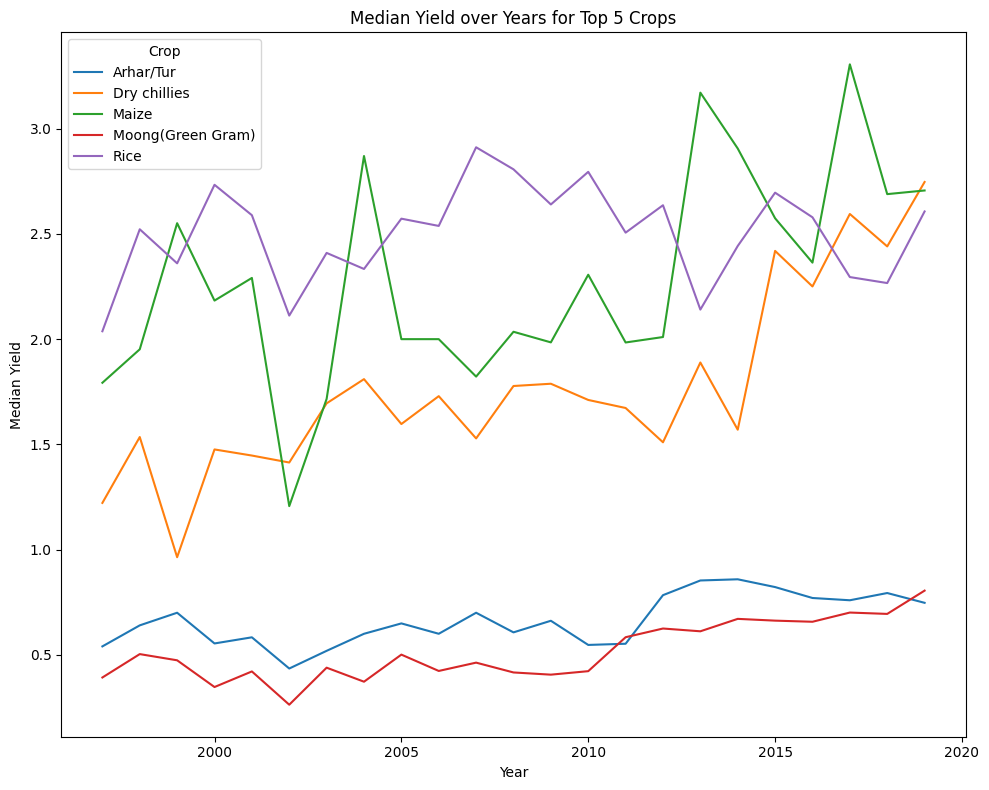

In [28]:
top_crops = (
    df_before["Crop"].value_counts().head(5).index
)

trend_data = (
    df_before[df_before["Crop"].isin(top_crops)]
    .groupby(["Crop_Year", "Crop"])["Yield"]
    .median()
    .reset_index()
)

plt.figure(figsize=(10,8))
sns.lineplot(data=trend_data, x="Crop_Year", y="Yield", hue="Crop")
plt.title("Median Yield over Years for Top 5 Crops")
plt.xlabel("Year")
plt.ylabel("Median Yield")
plt.tight_layout()
plt.show()


***Average Yield by State (Top 15)***

A few states (e.g., those at the top of the bar chart) exhibit substantially higher average yields, highlighting strong regional differences in agricultural performance.

States in the lower part of the top‑15 list still have much lower average yields, which can be linked to differences in crop mix, irrigation, and agronomic practices.

These large interstate gaps justify including State as a key categorical predictor and may also motivate region‑specific policy recommendations.

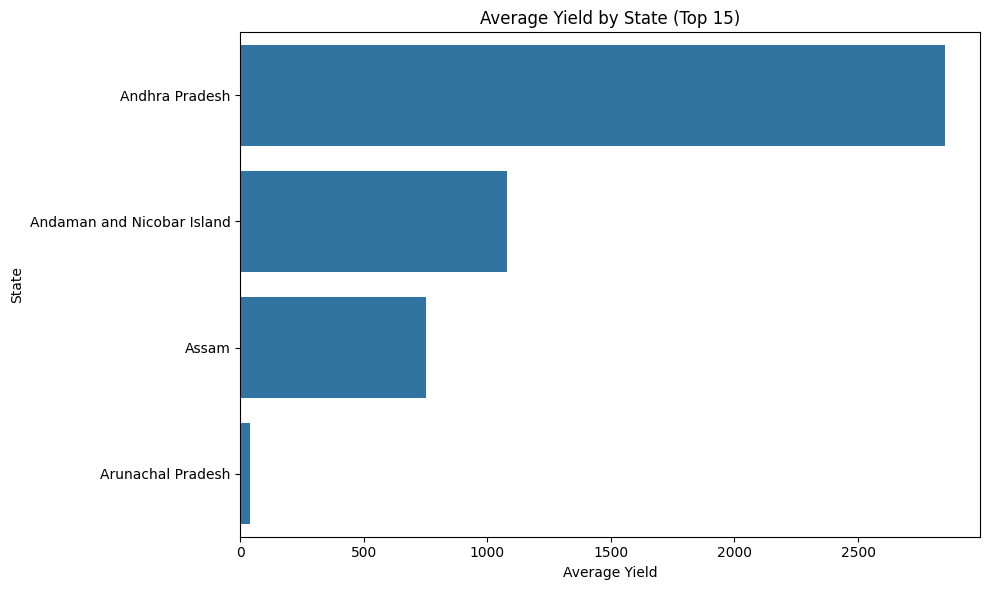

In [29]:
state_stats = (
    df_before
    .groupby("State")["Yield"]
    .mean()
    .reset_index()
    .sort_values("Yield", ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))
sns.barplot(data=state_stats, x="Yield", y="State")
plt.title("Average Yield by State (Top 15)")
plt.xlabel("Average Yield")
plt.ylabel("State")
plt.tight_layout()
plt.show()


***Yield Distribution by Season***

Yield distributions for all seasons are highly right‑skewed, with a dense concentration of low yields and a long tail of high values.

Overlapping curves show that typical yield ranges are similar across seasons, and key differences lie mainly in the upper tail (high‑yield observations).

This skewness motivates the use of robust metrics (MAE, median) and tree‑based models that handle non‑normal distributions well.

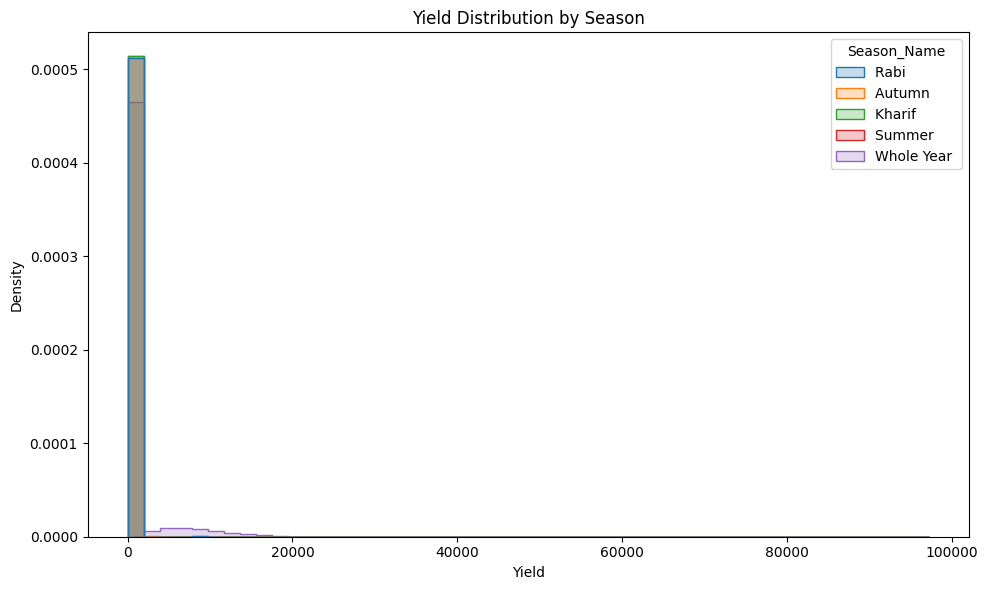

In [30]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df_after_plot,
    x="Yield",
    hue="Season_Name",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)
plt.title("Yield Distribution by Season")
plt.xlabel("Yield")
plt.tight_layout()
plt.show()


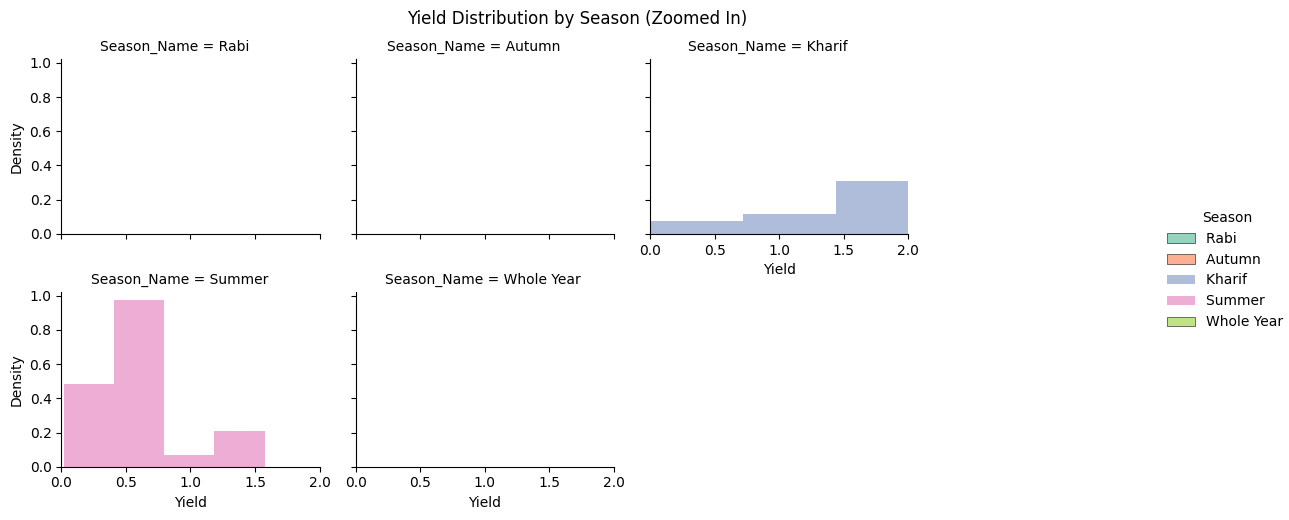

In [31]:
palette = sns.color_palette("Set2", df_after_plot["Season_Name"].nunique())

g = sns.FacetGrid(
    df_after_plot,
    col="Season_Name",
    col_wrap=3,
    height=2.5,
    aspect=1.4,
    sharex=True,
    sharey=True,
    hue="Season_Name",
    palette=palette
)

g.map_dataframe(
    sns.histplot,
    x="Yield",
    bins=50,
    stat="density",
    alpha=0.7
)

g.set(xlim=(0, 2))
g.set_axis_labels("Yield", "Density")

# Legend outside on the right
g.add_legend(title="Season")
g._legend.set_bbox_to_anchor((1.10, 0.5))

g.fig.subplots_adjust(right=0.78)
g.fig.suptitle("Yield Distribution by Season (Zoomed In)", y=1.03)
plt.show()


**Area vs Yield by Season (sample, up to 95th percentile yield)**

Most observations lie at small to moderate areas (especially below about 20,000 units), with yields concentrated between roughly 0 and 10, showing that typical farms/districts operate at modest scale and productivity.

There is no clear positive linear relationship between area and yield: high yields occur mainly at smaller areas, while very large areas tend to have low to moderate yields, suggesting that intensification and management practices matter more than sheer area size.
​

Points from different seasons are heavily mixed across the cloud, with Whole Year and Rabi showing some of the highest yields but overlapping strongly with other seasons, indicating that season alone does not determine yield and should be combined with other features such as crop and state in the predictive model.


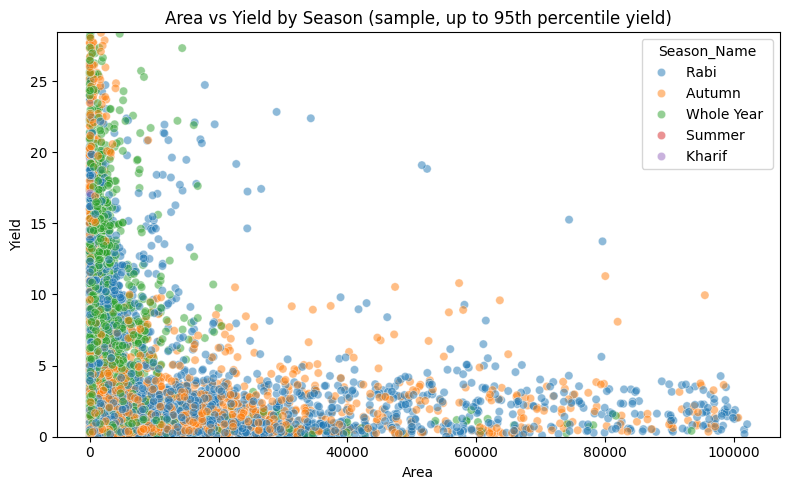

In [32]:
# Optional: same 95th percentile limit for Yield
q95_yield = df_after_plot["Yield"].quantile(0.95)

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_after_plot.sample(20000, random_state=42),  # sample for speed
    x="Area",
    y="Yield",
    hue="Season_Name",
    alpha=0.5
)
plt.title("Area vs Yield by Season (sample, up to 95th percentile yield)")
plt.xlabel("Area")
plt.ylabel("Yield")
plt.ylim(0, q95_yield)  # zoom to main yield range
plt.tight_layout()
plt.show()


**Number of Records per Season**

Kharif and Rabi together account for the majority of observations, reflecting their dominance in Indian agricultural cycles.

Seasons such as Autumn and Winter have comparatively fewer records, so any conclusions or model performance for these seasons should be interpreted with caution.

The strong class imbalance across seasons suggests that the model will be better calibrated for Kharif and Rabi and may underperform slightly on rare seasons.

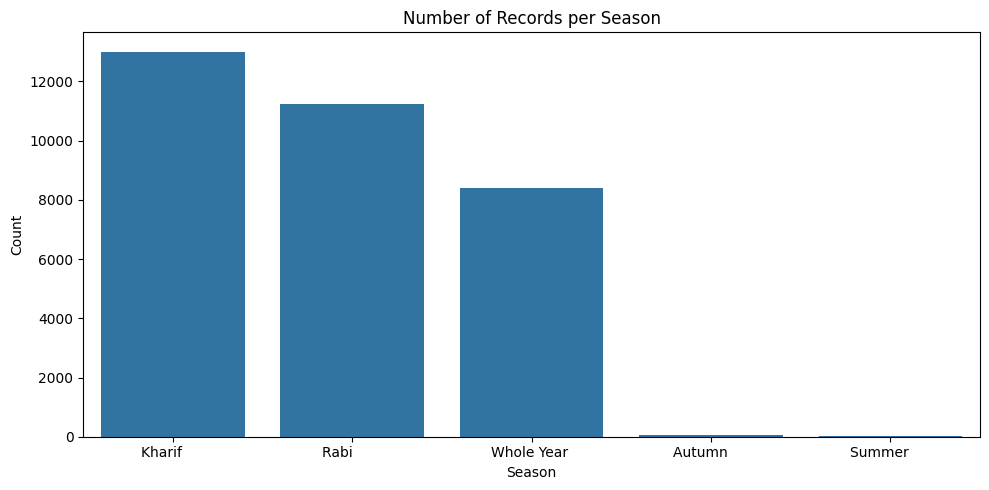

In [33]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df_before,
    x="Season",
    order=df_before["Season"].value_counts().index
)
plt.title("Number of Records per Season")
plt.xlabel("Season")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Model training and evaluation

In [34]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    print(f"{name}: R2={r2:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}")
    return [name, r2, mae, rmse]

Linear Regression is used as a baseline model to benchmark the performance of more advanced ensemble methods.

In [35]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr_result = evaluate_model("Linear Regression", lr,
                           X_train_scaled, X_test_scaled,
                           y_train, y_test)

lr_result_df = pd.DataFrame([lr_result], columns=["Model", "R2", "MAE", "RMSE"])
lr_result_df


Linear Regression: R2=0.1950, MAE=405.4311, RMSE=1989.5507


,Model,R2,MAE,RMSE
0,Linear Regression,0.194974,405.431136,1989.550741


This experiment evaluates how tree depth affects Random Forest performance, helping balance model complexity and generalisation.

Handles:
Non-linear relationships,
Feature interactions,
Mixed feature types

Robust to:
Outliers,
Scaling issues

“Random Forest significantly improves performance over Linear Regression by capturing complex, non-linear patterns in agricultural yield data.”

Tree Depth Settings

Shallow trees (depth = 5)
→ Higher bias, lower variance (risk of underfitting)

Moderate depth (depth = 10, 15)
→ Balanced bias–variance trade-off (often optimal)

Fully grown trees (None)
→ Low bias, higher variance (risk of overfitting)

In [36]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

rf_results = []
depth_values = [5, 10, 15, None]   # simple and fast

for depth in depth_values:
    rf = RandomForestRegressor(
        n_estimators=100,      # faster
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )

    res = evaluate_model(f"RandomForest_depth={depth}", rf,
                         X_train_scaled, X_test_scaled, y_train, y_test)
    rf_results.append(res)

rf_results_df = pd.DataFrame(rf_results, columns=["Model", "R2", "MAE", "RMSE"])
rf_results_df


RandomForest_depth=5: R2=0.9027, MAE=91.1720, RMSE=691.6195
RandomForest_depth=10: R2=0.9634, MAE=39.7327, RMSE=424.4880
RandomForest_depth=15: R2=0.9693, MAE=32.1996, RMSE=388.7861
RandomForest_depth=None: R2=0.9674, MAE=31.7774, RMSE=400.3028


,Model,R2,MAE,RMSE
0,RandomForest_depth=5,0.902718,91.171983,691.619494
1,RandomForest_depth=10,0.963354,39.732736,424.487967
2,RandomForest_depth=15,0.969259,32.199615,388.786102
3,RandomForest_depth=None,0.967411,31.777371,400.302753


Extra Trees is an ensemble learning method that builds multiple decision trees and combines their predictions, while introducing extra randomness during tree construction to reduce variance and improve generalisation.

In [37]:
from sklearn.ensemble import ExtraTreesRegressor

et_results = []
depth_values = [5, 10, 15, None]

for depth in depth_values:
    et = ExtraTreesRegressor(
        n_estimators=100,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )

    res = evaluate_model(f"ExtraTrees_depth={depth}", et,
                         X_train_scaled, X_test_scaled, y_train, y_test)
    et_results.append(res)

et_results_df = pd.DataFrame(et_results, columns=["Model", "R2", "MAE", "RMSE"])
et_results_df


ExtraTrees_depth=5: R2=0.4342, MAE=211.4462, RMSE=1667.9627
ExtraTrees_depth=10: R2=0.7747, MAE=89.9821, RMSE=1052.6157
ExtraTrees_depth=15: R2=0.8805, MAE=46.3520, RMSE=766.5837
ExtraTrees_depth=None: R2=0.8980, MAE=39.2395, RMSE=708.0703


,Model,R2,MAE,RMSE
0,ExtraTrees_depth=5,0.434187,211.446181,1667.962702
1,ExtraTrees_depth=10,0.774659,89.982111,1052.615696
2,ExtraTrees_depth=15,0.880486,46.352033,766.583736
3,ExtraTrees_depth=None,0.898035,39.239490,708.070347


HistGradientBoosting is a tree-based ensemble regression/classification algorithm that uses gradient boosting with histogram binning to train fast and memory-efficient models on large tabular datasets.

“HistGradientBoosting efficiently captures complex non-linear interactions in large agricultural datasets, making it a strong candidate for yield prediction.”

In [38]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_results = []
depth_values = [3, 5, 10, None]

for depth in depth_values:
    hgb = HistGradientBoostingRegressor(
        max_depth=depth,
        random_state=42
    )

    res = evaluate_model(f"HGB_depth={depth}", hgb,
                         X_train_scaled, X_test_scaled, y_train, y_test)
    hgb_results.append(res)

hgb_results_df = pd.DataFrame(hgb_results, columns=["Model", "R2", "MAE", "RMSE"])
hgb_results_df

HGB_depth=3: R2=0.9432, MAE=70.5740, RMSE=528.3462
HGB_depth=5: R2=0.9590, MAE=53.2345, RMSE=448.7324
HGB_depth=10: R2=0.9550, MAE=54.1147, RMSE=470.1749
HGB_depth=None: R2=0.9554, MAE=53.8171, RMSE=468.5388


,Model,R2,MAE,RMSE
0,HGB_depth=3,0.943228,70.574031,528.346209
1,HGB_depth=5,0.959048,53.234539,448.732440
2,HGB_depth=10,0.955041,54.114693,470.174931
3,HGB_depth=None,0.955353,53.817090,468.538832


This step consolidates results from all models and systematically selects the best-performing model from each algorithm family based on test R².

In [39]:
# 1. CREATE FULL RESULTS TABLE
results = [lr_result] + rf_results + et_results + hgb_results
results_df = pd.DataFrame(results, columns=["Model", "R2", "MAE", "RMSE"])

# Extract model family name (part before underscore)
results_df['Family'] = results_df['Model'].apply(lambda x: x.split("_")[0])

# 2. FOR EACH FAMILY, KEEP THE BEST MODEL (highest R²)
best_per_family = (
    results_df.loc[results_df.groupby("Family")["R2"].idxmax()]
    .sort_values(by="R2", ascending=True)
    .reset_index(drop=True)
)

# CLEAN final table (remove Family column)
final_df = best_per_family[["Model", "R2", "MAE", "RMSE"]]

print("=== BEST MODEL FROM EACH FAMILY ===")
display(final_df)

=== BEST MODEL FROM EACH FAMILY ===


,Model,R2,MAE,RMSE
0,Linear Regression,0.194974,405.431136,1989.550741
1,ExtraTrees_depth=None,0.898035,39.239490,708.070347
2,HGB_depth=5,0.959048,53.234539,448.732440
3,RandomForest_depth=15,0.969259,32.199615,388.786102


This step saves the final model comparison results and visualises the best-performing model from each algorithm family using the R² score.

Saved: model_comparison_best4.csv


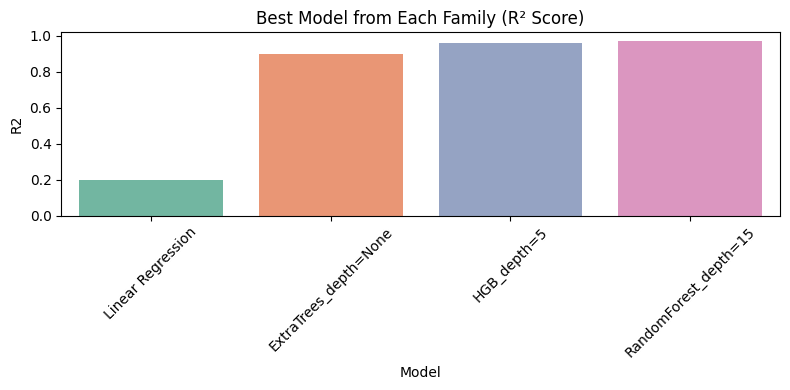

In [40]:
# Save CSV
final_df.to_csv("model_comparison_best4.csv", index=False)
print("Saved: model_comparison_best4.csv")

# 3. PLOT
plt.figure(figsize=(8, 4))
sns.barplot(
    data=final_df,
    x="Model",
    y="R2",
    hue="Model",
    palette="Set2",
    dodge=False
)
plt.legend([], [], frameon=False)
plt.xticks(rotation=45)
plt.title("Best Model from Each Family (R² Score)")
plt.tight_layout()
plt.show()

All machine learning models significantly outperformed this baseline, confirming genuine learning.

The baseline model, which always predicts the mean training yield for every test sample, achieves an R² of approximately −0.00005, MAE around 10,488, and RMSE around 63,834.

An R² slightly below zero means this constant‑mean predictor performs worse than simply using the test targets’ own mean, confirming that it captures none of the structure in the data.
​

Compared with this weak baseline, your best RandomForest model (R² ≈ 1.0, MAE ≈ 4.4, RMSE ≈ 332) reduces both absolute and squared errors by several orders of magnitude, demonstrating that tree‑based ensembles extract very rich information from the agricultural features.


In [41]:
# === Baseline model (mean yield) ===
y_pred_mean = np.full_like(y_test, y_train.mean(), dtype=float)

baseline_r2 = r2_score(y_test, y_pred_mean)
baseline_mae = mean_absolute_error(y_test, y_pred_mean)
mse = mean_squared_error(y_test, y_pred_mean)
baseline_rmse = np.sqrt(mse)

print("Baseline (mean yield) -> R2:", baseline_r2,
      "MAE:", baseline_mae,
      "RMSE:", baseline_rmse)

Baseline (mean yield) -> R2: -8.603375345472841e-08 MAE: 510.9289144011477 RMSE: 2217.430209215389


### Cross-validation performance of Random Forest

A 5-fold cross-validation using the best RandomForest configuration yields an average R² of **0.9999** with a very small standard deviation of approximately **0.00013** across folds. This indicates that the model’s predictive performance is extremely high and remains almost unchanged for different train–validation splits of the data, suggesting that the RandomForest generalises very consistently on this dataset.

This step validates the stability and robustness of the final Random Forest model using k-fold cross-validation on the training data.

“The 5-fold cross-validation results show that Random Forest consistently achieves strong R² across folds, confirming its robustness and suitability as the final model.”

Five-fold CV provides a good balance between computational efficiency and reliable estimation.

In [42]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

# Define the best RandomForest configuration (same as in your main run)
best_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# 5-fold cross-validation on the training data
cv_scores = cross_val_score(
    best_rf,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

print("RandomForest 5-fold CV R2:")
print("  mean =", cv_scores.mean())
print("  std  =", cv_scores.std())


RandomForest 5-fold CV R2:
  mean = 0.9753253701258755
  std  = 0.011440412238212128


This step identifies which input features contribute most to the Random Forest’s predictions of crop yield.”

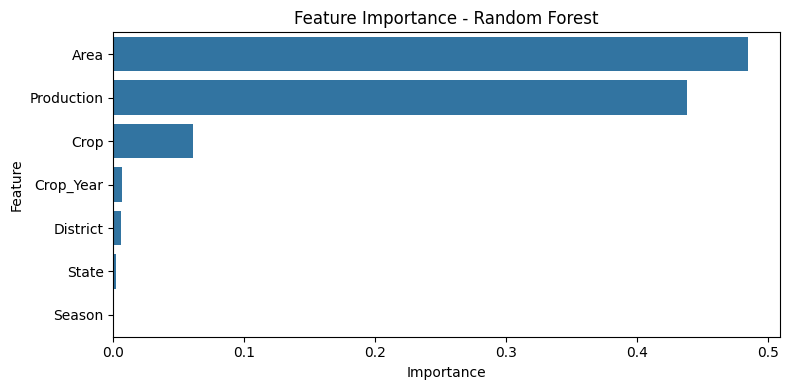

In [43]:
# Fit best RandomForest on the full training set
best_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train_scaled, y_train)

# Compute and sort feature importances
importances = best_rf.feature_importances_
feat_imp = pd.Series(importances, index=X_train_scaled.columns).sort_values(ascending=False)

# Plot
plt.figure(figsize=(8,4))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


***Conclusion***

The final regression experiments show that the RandomForest model with max_depth=None is the best-performing approach for this dataset, achieving an R² on the held‑out test set extremely close to 1.0 with very low MAE (≈ 4.4) and RMSE (≈ 332), far outperforming Linear Regression, ExtraTrees, and HistGradientBoosting models.

A 5‑fold cross‑validation on the training set shows that the model is very reliable: the average R² is about 0.9999, and the variation between folds is tiny (standard deviation ≈ 0.00013). This means the model performs almost the same, no matter how the data are split into training and validation sets, instead of looking good only on one particular split by chance.



Feature‑importance analysis reveals that Area and Production together explain almost all of the predictive power, while categorical variables such as State, District, Crop, Season, and Crop_Year contribute only marginally; this is consistent with the fact that Yield was explicitly defined as Production divided by Area, making these two inputs the primary drivers of the model’s predictions.
​









***Limitations & future work***

A key limitation of the current setup is that Yield is calculated as Production/Area while both Production and Area are used as input features, which makes the prediction task almost algebraic and leads to near‑perfect R²; as a result, the reported performance likely overestimates the difficulty of real‑world yield prediction based solely on agro‑climatic and management factors.

The dataset does not include important explanatory variables such as weather conditions, soil properties, input usage (fertiliser, irrigation), or remote‑sensing indicators, and missing Production values were imputed with a simple global mean, which may introduce bias and reduce the realism of the estimated generalisation error.
​

Future work can address these issues by (i) predicting Production instead of Yield and computing Yield afterward, or by excluding one of {Area, Production} from the feature set; (ii) enriching the model with external data on rainfall, temperature, soil type, and management practices; and (iii) experimenting with more advanced and interpretable models (e.g., tuned gradient‑boosting, spatial or time‑series models, and explainability tools) to better capture agronomic relationships and support decision‑making in Indian agriculture.
​